<div style="background: linear-gradient(135deg, #5e2a8e 0%, #8e44ad 25%, #a569bd 50%, #bb8fce 75%, #d2b4de 100%); padding: 50px; border-radius: 15px; text-align: center; box-shadow: 0 10px 30px rgba(0,0,0,0.5);">
    <h1 style="color: #ffffff; font-size: 46px; margin: 0; text-shadow: 3px 3px 6px rgba(0,0,0,0.6); font-weight: bold; letter-spacing: 2px;">Pakistani Air Quality Analysis 2025-2026</h1>
    <p style="color: #f5eef8; font-size: 20px; margin-top: 15px; font-style: italic; text-shadow: 2px 2px 4px rgba(0,0,0,0.4);">Phase 3: Feature Engineering</p>
</div>

<div style="background-color: #000000; padding: 25px; border-radius: 12px; color: #ffffff; margin-top: 15px;">
    <h2 style="margin-top: 0; color: #bb8fce;">Abstract</h2>
    <p style="font-size: 16px; line-height: 1.7; color: #dddddd;">This phase performs systematic feature engineering on the preprocessed Pakistani Air Quality dataset (21,840 records x 21 features) built in Phase 2. The target variable is <strong>PM2.5 concentration</strong> - a critical air quality metric linked to respiratory and cardiovascular disease. We identify important features using <strong>5 algorithms</strong> (Random Forest, XGBoost, LightGBM, Permutation Importance, Mutual Information) and explain model behaviour using <strong>SHAP</strong> and <strong>LIME</strong>. New domain-informed features are engineered across five groups: pollution ratios, meteorological interactions, cyclical time encodings, lag/rolling statistics, and K-Means cluster labels. Low-value features are dropped with justification. The final dataset is saved in two formats - <em>raw</em> (for tree models) and <em>scaled</em> (for distance-based models) - ready for Phase 4 Model Training.</p>
</div>

<div style="background-color: #1a1a1a; padding: 20px; border-radius: 10px; color: #ffffff; margin-top: 10px;">
    <h3 style="margin-top: 0; color: #bb8fce;">Table of Contents</h3>
    <ol style="font-size: 16px; line-height: 2; color: #cccccc;">
        <li>Import Libraries and Load Data</li>
        <li>Quick Data Sanity Check</li>
        <li>Baseline LightGBM Performance</li>
        <li>Feature Importance - 5 Algorithms</li>
        <li>SHAP Analysis</li>
        <li>LIME Analysis</li>
        <li>Engineering New Features</li>
        <li>Validating New Features</li>
        <li>Dropping Low-Importance Features</li>
        <li>Standardization and Normalization</li>
        <li>K-Means Clustering as a New Feature</li>
        <li>Final Performance Summary</li>
        <li>Save Datasets for Phase 4</li>
    </ol>
</div>

## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans

import xgboost as xgb
import lightgbm as lgb
import shap
import lime
import lime.lime_tabular

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('All libraries imported successfully!')

All libraries imported successfully!


In [20]:
# Load the preprocessed dataset saved at end of Phase 2
# Update path to match your Kaggle input dataset
df = pd.read_csv('/kaggle/input/datasets/zainf2327/phase-2-visualization-and-eda-output/processed_air_quality_data.csv')

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (21840, 20)


,city,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,temperature,humidity,precipitation,wind_speed,wind_direction,pressure,hour,day_of_week,month,year,is_weekend,season
0,0,23.7,22.6,598.0,15.9,5.0,58.0,2.0,16.8,70.0,0.0,1.0,45.0,1023.4,0,4,11,2025,0,0
1,0,25.4,24.2,790.0,21.7,5.6,51.0,2.0,16.8,70.0,0.0,1.0,45.0,1023.4,1,4,11,2025,0,0
2,0,32.2,30.7,1048.0,29.4,6.5,42.0,2.0,16.8,70.0,0.0,1.0,45.0,1023.4,2,4,11,2025,0,0
3,0,36.2,34.8,1176.0,33.2,7.2,42.0,2.0,16.8,70.0,0.0,1.0,45.0,1023.4,3,4,11,2025,0,0
4,0,34.7,33.3,1053.0,29.3,7.6,58.0,2.0,16.8,70.0,0.0,1.0,45.0,1023.4,4,4,11,2025,0,0


## 2. Quick Data Sanity Check

Before engineering features we confirm the Phase 2 dataset has no silent corruption, no new nulls, and correct dtypes.

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21840 entries, 0 to 21839
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   city              21840 non-null  int64  
 1   pm10              21840 non-null  float64
 2   pm2_5             21840 non-null  float64
 3   carbon_monoxide   21840 non-null  float64
 4   nitrogen_dioxide  21840 non-null  float64
 5   sulphur_dioxide   21840 non-null  float64
 6   ozone             21840 non-null  float64
 7   dust              21840 non-null  float64
 8   temperature       21840 non-null  float64
 9   humidity          21840 non-null  float64
 10  precipitation     21840 non-null  float64
 11  wind_speed        21840 non-null  float64
 12  wind_direction    21840 non-null  float64
 13  pressure          21840 non-null  float64
 14  hour              21840 non-null  int64  
 15  day_of_week       21840 non-null  int64  
 16  month             21840 non-null  int64 

In [22]:
print('Missing values:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())

Missing values:
city                0
pm10                0
pm2_5               0
carbon_monoxide     0
nitrogen_dioxide    0
sulphur_dioxide     0
ozone               0
dust                0
temperature         0
humidity            0
precipitation       0
wind_speed          0
wind_direction      0
pressure            0
hour                0
day_of_week         0
month               0
year                0
is_weekend          0
season              0
dtype: int64

Duplicate rows: 0


In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
city,21840.0,4.500000,2.872347,0.0,2.00,4.5,7.00,9.0
pm10,21840.0,88.416575,66.010440,0.5,40.50,68.5,117.80,488.0
pm2_5,21840.0,82.968141,65.742106,0.5,34.70,62.4,112.50,486.2
carbon_monoxide,21840.0,1580.858700,1145.632800,91.0,741.00,1296.5,2113.25,11482.0
nitrogen_dioxide,21840.0,39.470870,32.286339,0.0,13.40,30.4,57.80,185.1
sulphur_dioxide,21840.0,19.466383,11.582885,0.1,10.60,17.7,26.30,75.1
ozone,21840.0,63.802106,50.401229,0.0,21.00,55.0,100.00,265.0
dust,21840.0,9.858242,32.531054,0.0,1.00,3.0,8.00,711.0
temperature,21840.0,13.721964,5.043094,-5.9,10.20,13.3,16.90,30.4
humidity,21840.0,64.741667,20.267453,4.0,52.00,64.0,81.00,100.0


**Observation:** Dataset is clean with 21,840 rows, 20 columns, zero nulls and no duplicates. All columns are numeric as categorical features were label-encoded in Phase 2. The dataset is ready for feature engineering.

## 3. Baseline LightGBM Performance

We establish a baseline using LightGBM with default settings on the raw Phase 2 features. This is the reference benchmark against which every feature engineering decision will be measured.

> **Assignment Note:** LightGBM is used throughout Phase 3 only as a fast validation tool with default parameters - no hyperparameter tuning. Full model training and tuning might happen in Phase 4 if required.

In [26]:
TARGET = 'pm2_5'

X_base = df.drop(columns=[TARGET])
y_base = df[TARGET]

X_tr, X_te, y_tr, y_te = train_test_split(X_base, y_base, test_size=0.2, random_state=42)

lgb_base = lgb.LGBMRegressor(random_state=42, verbose=-1)
lgb_base.fit(X_tr, y_tr)
y_pred_base = lgb_base.predict(X_te)

results_tracker = []

def evaluate(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'  [{label}]')
    print(f'    RMSE: {rmse:.4f}   MAE: {mae:.4f}   R2: {r2:.4f}')
    return {'Stage': label, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results_tracker.append(evaluate(y_te, y_pred_base, 'Baseline - Phase 2 features only'))

  [Baseline - Phase 2 features only]
    RMSE: 1.6869   MAE: 0.8742   R2: 0.9993


## 4. Feature Importance - 5 Algorithms

Using a single importance method can be misleading as each algorithm has its own bias. By aggregating 5 methods we get a reliable consensus. Random Forest can overrate high-cardinality features, permutation importance can underrate correlated features, so combining them reduces individual biases.

| Method | Type | What it measures |
|---|---|---|
| Random Forest | Impurity-based | Mean decrease in node impurity |
| XGBoost | Gain-based | Average gain across all splits using a feature |
| LightGBM | Split-based | Number of times a feature is used to split |
| Permutation Importance | Model-agnostic | Drop in score when feature is randomly shuffled |
| Mutual Information | Statistical | Non-linear dependency between feature and target |

### 4.1 Random Forest

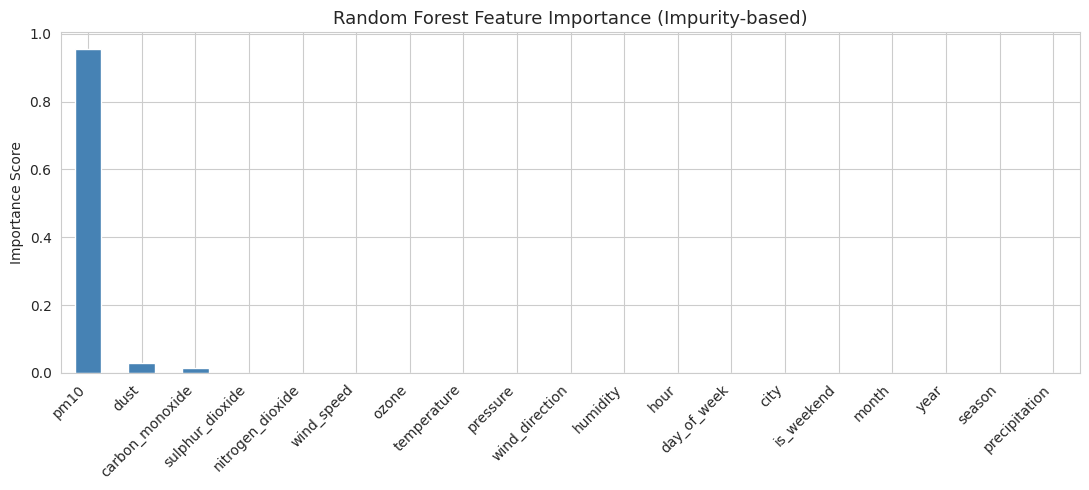

Top 10 (Random Forest):
pm10                0.956667
dust                0.028924
carbon_monoxide     0.013285
sulphur_dioxide     0.000473
nitrogen_dioxide    0.000240
wind_speed          0.000066
ozone               0.000061
temperature         0.000047
pressure            0.000046
wind_direction      0.000045


In [27]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

rf_imp = pd.Series(rf.feature_importances_, index=X_tr.columns).sort_values(ascending=False)

plt.figure(figsize=(11, 5))
rf_imp.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Random Forest Feature Importance (Impurity-based)', fontsize=13)
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 10 (Random Forest):')
print(rf_imp.head(10).to_string())

### 4.2 XGBoost

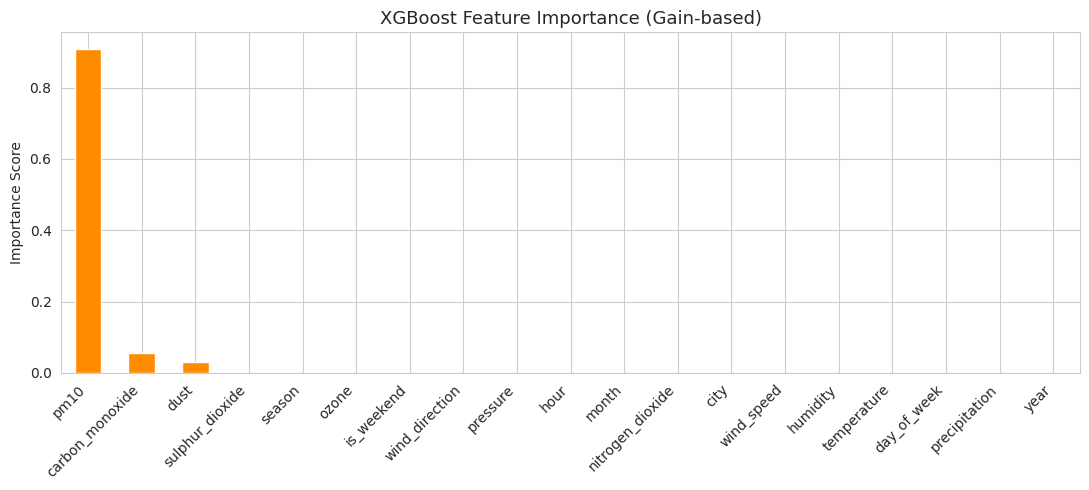

Top 10 (XGBoost):
pm10               0.909695
carbon_monoxide    0.056999
dust               0.029761
sulphur_dioxide    0.000612
season             0.000375
ozone              0.000316
is_weekend         0.000288
wind_direction     0.000279
pressure           0.000267
hour               0.000235


In [28]:
# Remove device='cuda' if not on GPU
xgb_model = xgb.XGBRegressor(n_estimators=200, random_state=42, verbosity=0, device='cuda')
xgb_model.fit(X_tr, y_tr)

xgb_imp = pd.Series(xgb_model.feature_importances_, index=X_tr.columns).sort_values(ascending=False)

plt.figure(figsize=(11, 5))
xgb_imp.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('XGBoost Feature Importance (Gain-based)', fontsize=13)
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 10 (XGBoost):')
print(xgb_imp.head(10).to_string())

### 4.3 LightGBM

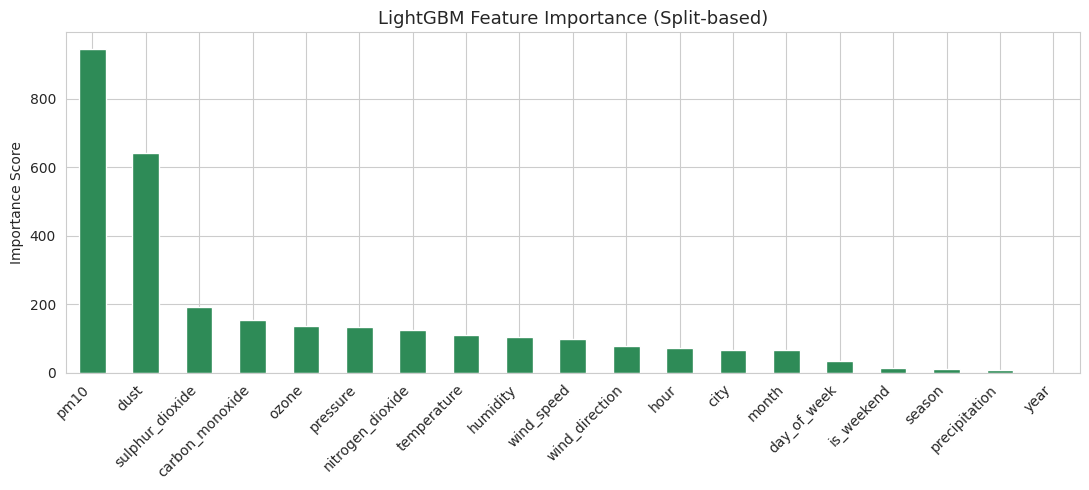

Top 10 (LightGBM):
pm10                946
dust                641
sulphur_dioxide     192
carbon_monoxide     154
ozone               136
pressure            133
nitrogen_dioxide    126
temperature         112
humidity            105
wind_speed           98


In [29]:
lgb_imp = pd.Series(lgb_base.feature_importances_, index=X_tr.columns).sort_values(ascending=False)

plt.figure(figsize=(11, 5))
lgb_imp.plot(kind='bar', color='seagreen', edgecolor='white')
plt.title('LightGBM Feature Importance (Split-based)', fontsize=13)
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 10 (LightGBM):')
print(lgb_imp.head(10).to_string())

### 4.4 Permutation Importance

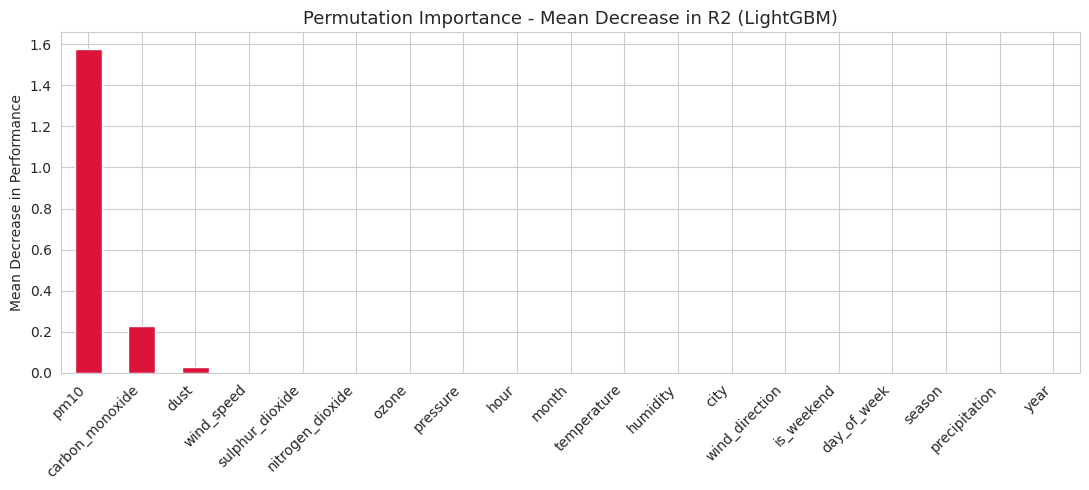

Top 10 (Permutation Importance):
pm10                1.578780
carbon_monoxide     0.228078
dust                0.030995
wind_speed          0.000115
sulphur_dioxide     0.000094
nitrogen_dioxide    0.000067
ozone               0.000053
pressure            0.000037
hour                0.000031
month               0.000031


In [30]:
perm = permutation_importance(lgb_base, X_te, y_te, n_repeats=15, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=X_te.columns).sort_values(ascending=False)

plt.figure(figsize=(11, 5))
perm_imp.plot(kind='bar', color='crimson', edgecolor='white')
plt.title('Permutation Importance - Mean Decrease in R2 (LightGBM)', fontsize=13)
plt.ylabel('Mean Decrease in Performance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 10 (Permutation Importance):')
print(perm_imp.head(10).to_string())

### 4.5 Mutual Information

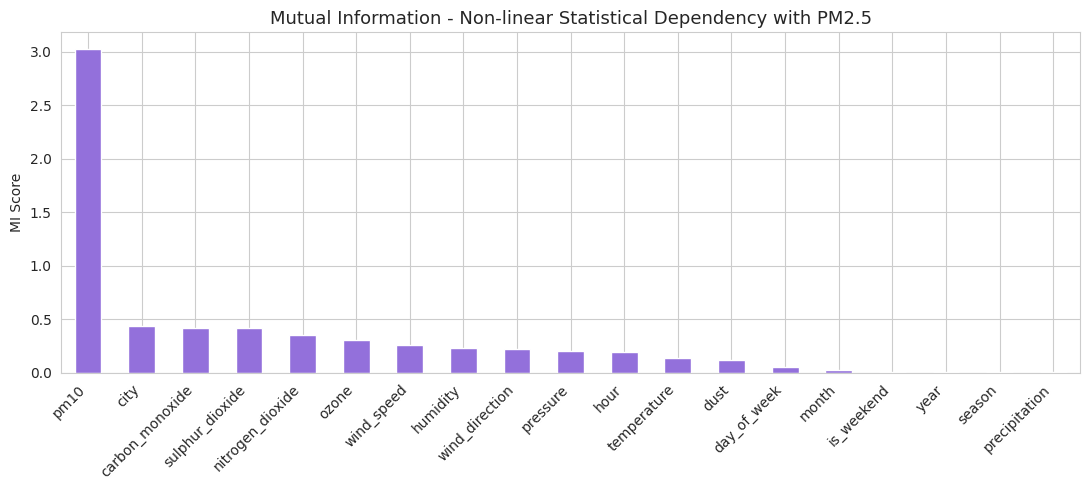

Top 10 (Mutual Information):
pm10                3.029098
city                0.434909
carbon_monoxide     0.416363
sulphur_dioxide     0.415500
nitrogen_dioxide    0.352157
ozone               0.303744
wind_speed          0.258663
humidity            0.232516
wind_direction      0.223440
pressure            0.208674


In [31]:
mi = mutual_info_regression(X_tr, y_tr, random_state=42)
mi_imp = pd.Series(mi, index=X_tr.columns).sort_values(ascending=False)

plt.figure(figsize=(11, 5))
mi_imp.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Mutual Information - Non-linear Statistical Dependency with PM2.5', fontsize=13)
plt.ylabel('MI Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 10 (Mutual Information):')
print(mi_imp.head(10).to_string())

### 4.6 Consensus Ranking - All 5 Methods Combined

Each method's scores are normalized to [0,1] and averaged to produce a consensus importance ranking.

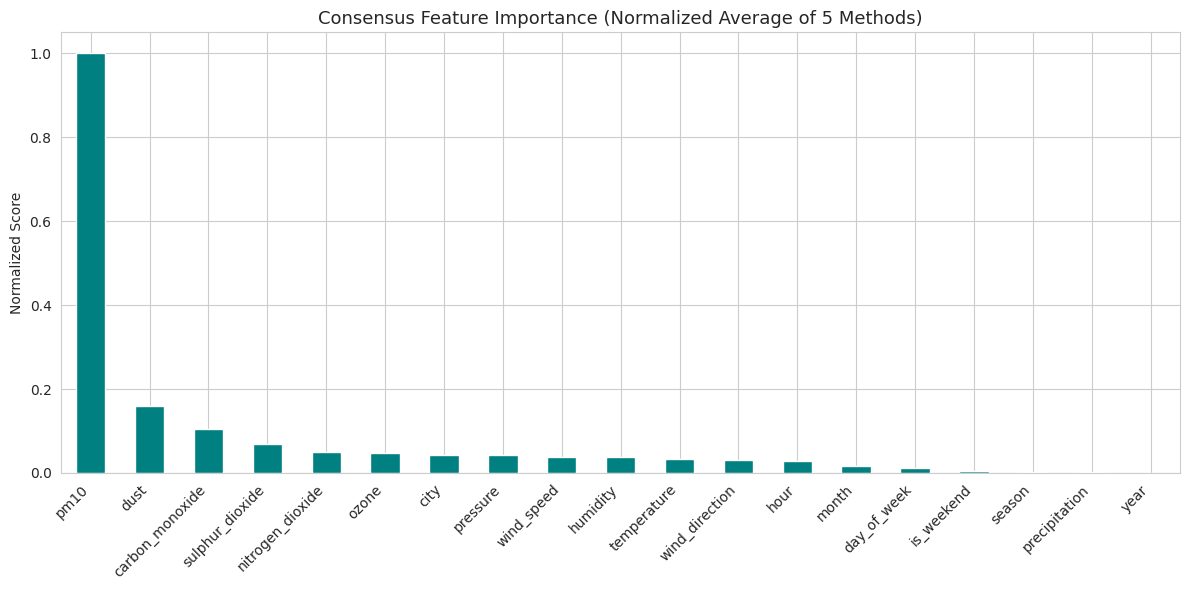

Full Consensus Ranking:
                  RandomForest  XGBoost  LightGBM  Permutation  MutualInformation  ConsensusScore
pm10                    1.0000   1.0000    1.0000       1.0000             1.0000          1.0000
dust                    0.0302   0.0327    0.6776       0.0196             0.0383          0.1597
carbon_monoxide         0.0139   0.0627    0.1628       0.1445             0.1361          0.1040
sulphur_dioxide         0.0005   0.0007    0.2030       0.0001             0.1358          0.0680
nitrogen_dioxide        0.0003   0.0002    0.1332       0.0000             0.1149          0.0497
ozone                   0.0001   0.0003    0.1438       0.0000             0.0989          0.0486
city                    0.0000   0.0002    0.0708       0.0000             0.1422          0.0427
pressure                0.0000   0.0003    0.1406       0.0000             0.0674          0.0417
wind_speed              0.0001   0.0002    0.1036       0.0001             0.0840          0.0

In [32]:
def normalize_series(s):
    rng = s.max() - s.min()
    return (s - s.min()) / (rng + 1e-10)

consensus = pd.DataFrame({
    'RandomForest'     : normalize_series(rf_imp),
    'XGBoost'          : normalize_series(xgb_imp),
    'LightGBM'         : normalize_series(lgb_imp),
    'Permutation'      : normalize_series(perm_imp),
    'MutualInformation': normalize_series(mi_imp),
}).fillna(0)

consensus['ConsensusScore'] = consensus.mean(axis=1)
consensus = consensus.sort_values('ConsensusScore', ascending=False)

plt.figure(figsize=(12, 6))
consensus['ConsensusScore'].plot(kind='bar', color='teal', edgecolor='white')
plt.title('Consensus Feature Importance (Normalized Average of 5 Methods)', fontsize=13)
plt.ylabel('Normalized Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Full Consensus Ranking:')
print(consensus.round(4).to_string())

**Key Observations from Importance Analysis:**
- **pm10** is consistently the top feature as fine and coarse particles share emission sources with PM2.5.
- **carbon_monoxide, nitrogen_dioxide, sulphur_dioxide** rank highly since all are produced by combustion from traffic and industry.
- **temperature and humidity** appear in mid-range as weather modulates how pollutants disperse and concentrate.
- **year, wind_direction, is_weekend** consistently score lowest across all 5 methods and are strong candidates for dropping.
- Even low-scoring features such as dust and precipitation can contribute when combined into new interaction features.

## 5. SHAP Analysis

SHAP (SHapley Additive exPlanations) is grounded in cooperative game theory. It assigns each feature a contribution value for each individual prediction and guarantees consistency and local accuracy. Unlike impurity-based importance, SHAP shows both magnitude and direction of impact. We use TreeExplainer which is exact and fast for LightGBM.

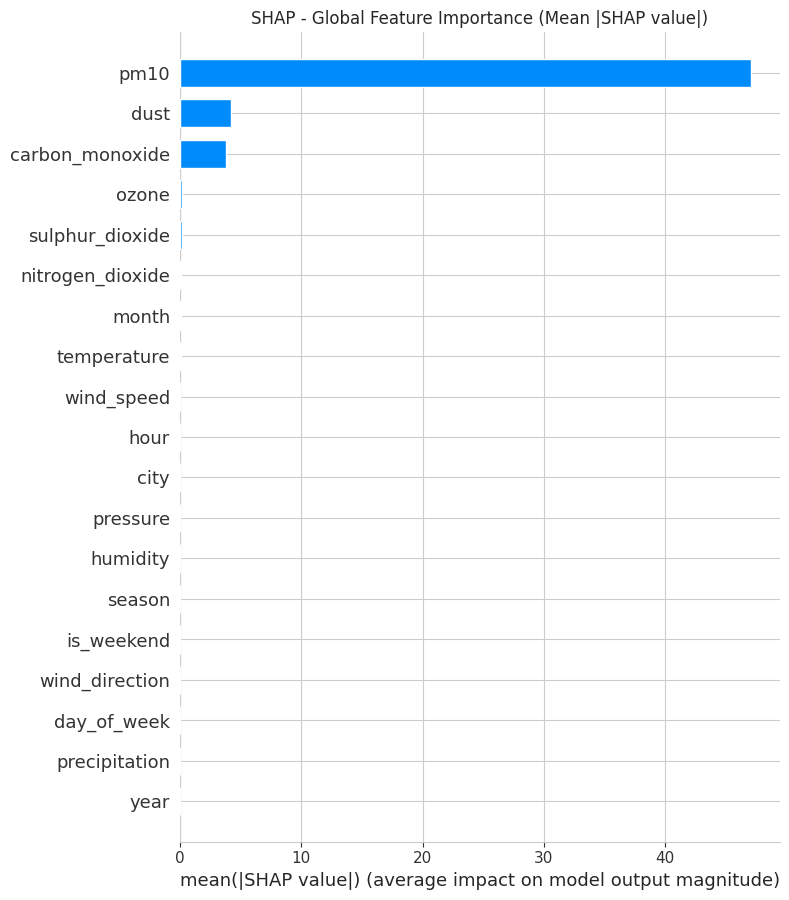

In [33]:
explainer = shap.TreeExplainer(lgb_base)
shap_values = explainer.shap_values(X_te)

plt.figure()
shap.summary_plot(shap_values, X_te, plot_type='bar', show=False)
plt.title('SHAP - Global Feature Importance (Mean |SHAP value|)')
plt.tight_layout()
plt.show()

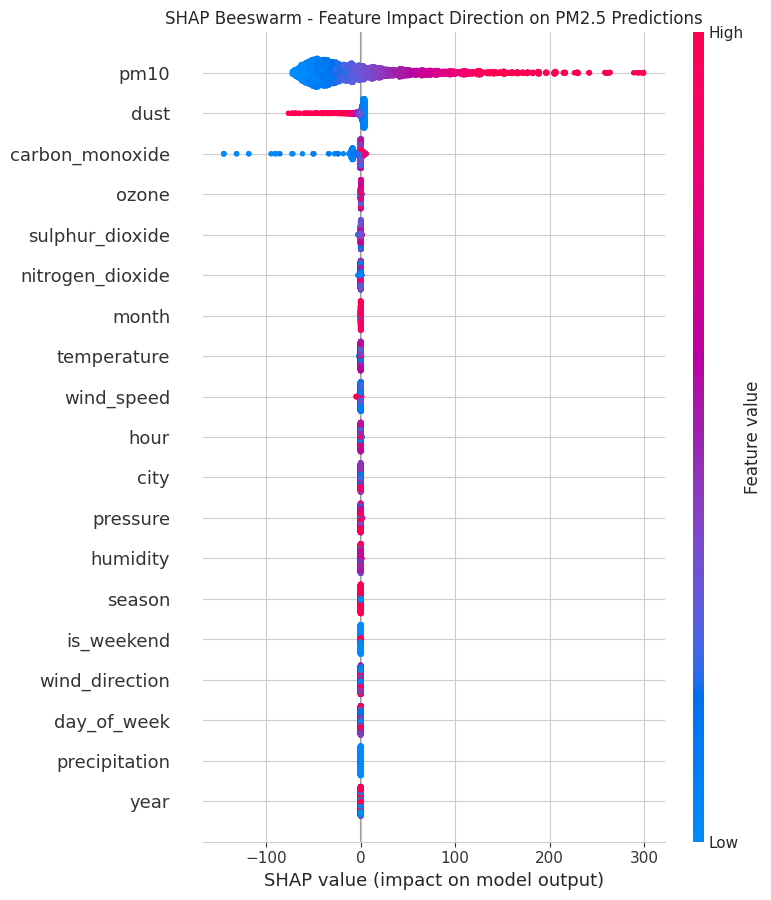

In [34]:
plt.figure()
shap.summary_plot(shap_values, X_te, show=False)
plt.title('SHAP Beeswarm - Feature Impact Direction on PM2.5 Predictions')
plt.tight_layout()
plt.show()

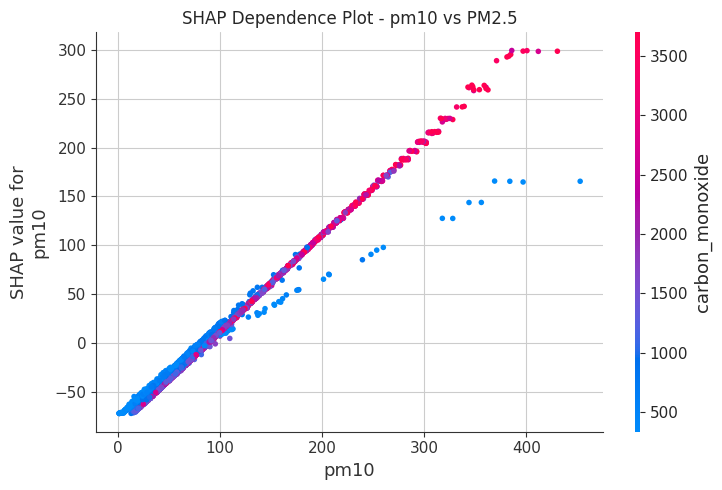

In [35]:
# Dependence plot for top feature
top_feature = consensus.index[0]
shap.dependence_plot(top_feature, shap_values, X_te, show=False)
plt.title(f'SHAP Dependence Plot - {top_feature} vs PM2.5')
plt.tight_layout()
plt.show()

**SHAP Interpretation:**
- Red dots (high feature value) on the right mean that feature value increases PM2.5 prediction.
- Blue dots (low feature value) on the left mean that feature value decreases PM2.5 prediction.
- pm10 and combustion pollutants push predictions upward when high, consistent with shared emission sources.
- wind_speed with high values shows negative SHAP values since wind disperses PM2.5, confirming the Phase 2 correlation finding of r = -0.33.
- temperature shows a mixed pattern where very low temperatures increase PM2.5 due to thermal inversions while moderate temperatures decrease it.

## 6. LIME Analysis

LIME (Local Interpretable Model-agnostic Explanations) explains individual predictions rather than global patterns. It fits a simple linear model around a single data point. Unlike SHAP which is global, LIME helps understand why the model made a specific prediction for one specific city-hour record. We explain 3 cases: a high-pollution record, a low-pollution record, and a median-pollution record.

High Pollution Record - Actual: 419.10, Predicted: 391.31


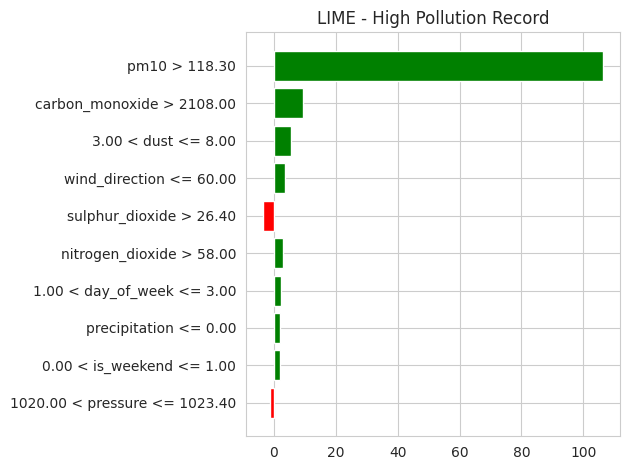

In [36]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_tr.values,
    feature_names = X_tr.columns.tolist(),
    mode          = 'regression',
    random_state  = 42
)

# High pollution sample
high_pos = y_te.values.argmax()
exp_high = lime_explainer.explain_instance(
    data_row   = X_te.iloc[high_pos].values,
    predict_fn = lgb_base.predict,
    num_features = 10
)
print(f'High Pollution Record - Actual: {y_te.iloc[high_pos]:.2f}, Predicted: {lgb_base.predict(X_te.iloc[[high_pos]])[0]:.2f}')
exp_high.as_pyplot_figure()
plt.title('LIME - High Pollution Record')
plt.tight_layout()
plt.show()

Low Pollution Record - Actual: 0.90, Predicted: 2.02


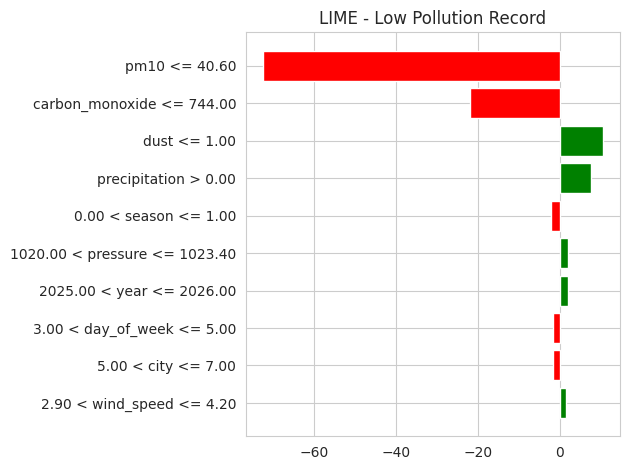

In [37]:
# Low pollution sample
low_pos = y_te.values.argmin()
exp_low = lime_explainer.explain_instance(
    data_row   = X_te.iloc[low_pos].values,
    predict_fn = lgb_base.predict,
    num_features = 10
)
print(f'Low Pollution Record - Actual: {y_te.iloc[low_pos]:.2f}, Predicted: {lgb_base.predict(X_te.iloc[[low_pos]])[0]:.2f}')
exp_low.as_pyplot_figure()
plt.title('LIME - Low Pollution Record')
plt.tight_layout()
plt.show()

Median Pollution Record - Actual: 61.20, Predicted: 60.56


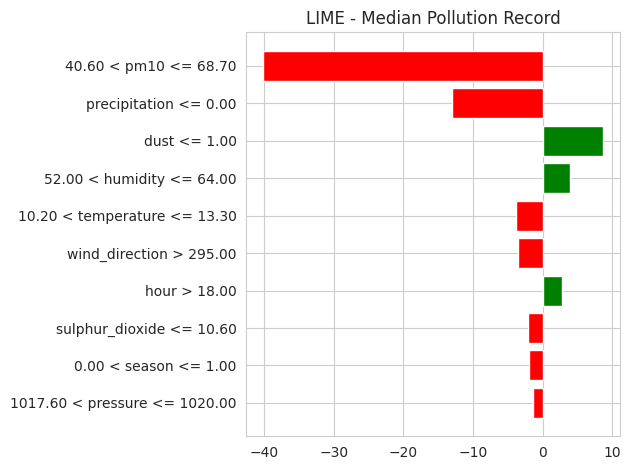

In [38]:
# Median pollution sample
median_pos = np.abs(y_te.values - y_te.median()).argmin()
exp_med = lime_explainer.explain_instance(
    data_row   = X_te.iloc[median_pos].values,
    predict_fn = lgb_base.predict,
    num_features = 10
)
print(f'Median Pollution Record - Actual: {y_te.iloc[median_pos]:.2f}, Predicted: {lgb_base.predict(X_te.iloc[[median_pos]])[0]:.2f}')
exp_med.as_pyplot_figure()
plt.title('LIME - Median Pollution Record')
plt.tight_layout()
plt.show()

**LIME Interpretation:**
- Green bars show features that pushed this specific prediction higher toward more pollution.
- Red bars show features that pushed this prediction lower toward less pollution.
- For the high-pollution record high pm10 and low wind_speed are the main drivers.
- For the low-pollution record low combustion pollutants and higher wind create cleaner conditions.
- LIME confirms that our model has learned physically meaningful relationships rather than statistical artifacts.

## 7. Engineering New Features

Based on the consensus importance rankings, SHAP directions, and air quality domain knowledge we engineer new features across 5 groups. Note that even low-importance features are considered for combinations since a weak predictor alone can become powerful in an interaction term.

In [39]:
df_fe = df.copy()
df_fe = df_fe.sort_values(['city', 'month', 'day_of_week', 'hour']).reset_index(drop=True)
original_features = df_fe.columns.tolist()
print(f'Starting with {len(original_features)} features')

Starting with 20 features


### 7.1 Pollution Ratio Features

**Significance and Why Required:** The ratio between pollutants is more diagnostic than absolute values alone. The PM2.5/PM10 ratio (fine particle fraction) indicates whether pollution is dominated by fine combustion particles (ratio close to 1) or coarse dust particles (ratio close to 0). In Pakistani cities, high ratios during winter indicate heavy vehicle and biomass burning. CO/NO2 and SO2/NO2 ratios help distinguish traffic-dominated pollution from industrial and coal sources, which is critical since cities like Faisalabad have different emission profiles compared to Quetta.

In [44]:
# Fine particle fraction - closer to 1 means more combustion-sourced PM
df_fe['pm25_pm10_ratio'] = df_fe['pm2_5'] / (df_fe['pm10'] + 1e-5)

# Traffic vs industrial signature - high CO/NO2 means more vehicle emissions
df_fe['co_no2_ratio'] = df_fe['carbon_monoxide'] / (df_fe['nitrogen_dioxide'] + 1e-5)

# Industrial/coal signature - high SO2/NO2 means coal burning or heavy industry
df_fe['so2_no2_ratio'] = df_fe['sulphur_dioxide'] / (df_fe['nitrogen_dioxide'] + 1e-5)

# Combined combustion burden - aggregate traffic and industrial pollutants
df_fe['combustion_index'] = (df_fe['carbon_monoxide'] +
                              df_fe['nitrogen_dioxide'] +
                              df_fe['sulphur_dioxide'])

# Dust contribution to particulate matter
df_fe['dust_pm10_ratio'] = df_fe['dust'] / (df_fe['pm10'] + 1e-5)

print('Pollution ratio features created successfully')
df_fe[['pm25_pm10_ratio','co_no2_ratio','so2_no2_ratio','combustion_index','dust_pm10_ratio']].describe()

Pollution ratio features created successfully


,pm25_pm10_ratio,co_no2_ratio,so2_no2_ratio,combustion_index,dust_pm10_ratio
count,21840.000000,2.184000e+04,2.184000e+04,21840.000000,21840.000000
mean,0.913221,5.053597e+04,5.345642e+02,1639.795952,0.163359
std,0.145120,1.203598e+06,1.635252e+04,1174.338181,0.310579
min,0.106054,3.398692e+00,2.747252e-03,108.800000,0.000000
25%,0.923351,2.896215e+01,3.092141e-01,776.150000,0.016584
50%,0.968674,4.593611e+01,4.999998e-01,1351.000000,0.046771
75%,0.986363,7.583016e+01,1.100499e+00,2191.700000,0.136719
max,1.000000,6.050000e+07,1.220000e+06,11724.300000,7.727238


### 7.2 Meteorological Interaction Features

**Significance and Why Required:** Weather variables interact in complex non-linear ways to either trap or disperse pollutants. High humidity combined with low wind speed creates stagnant moist air that keeps PM2.5 near the ground. High atmospheric pressure suppresses vertical mixing, allowing pollutants to accumulate near the surface. This is the core mechanism behind winter smog episodes in Lahore and Faisalabad. The inversion_proxy specifically captures this thermal inversion effect which is the key driver of Pakistan's worst pollution events. These interactions cannot be captured by individual weather features alone.

In [45]:
# Stagnation Index - high humidity + low wind = pollution trap (higher = worse)
df_fe['stagnation_index'] = df_fe['humidity'] / (df_fe['wind_speed'] + 0.1)

# Atmospheric inversion proxy - high pressure / cold temperature = trapped cold air layer
df_fe['inversion_proxy'] = df_fe['pressure'] / (df_fe['temperature'] + 273.15)

# Wind ventilation efficiency - wind disperses pollution but humidity reduces its effectiveness
df_fe['wind_ventilation'] = df_fe['wind_speed'] * (1 - df_fe['humidity'] / 100)

# Heat index - combined temperature-humidity effect on atmospheric mixing
df_fe['heat_index'] = df_fe['temperature'] * df_fe['humidity'] / 100

# Precipitation washout - rain physically removes particles from the air
df_fe['rain_washout'] = df_fe['precipitation'] * df_fe['humidity'] / 100

print('Meteorological interaction features created successfully')
df_fe[['stagnation_index','inversion_proxy','wind_ventilation','heat_index','rain_washout']].describe()

Meteorological interaction features created successfully


,stagnation_index,inversion_proxy,wind_ventilation,heat_index,rain_washout
count,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000
mean,21.622574,3.556926,2.186827,8.401082,0.015813
std,30.104299,0.066380,2.503667,3.007900,0.188771
min,0.318471,3.351013,0.000000,-4.176000,0.000000
25%,7.142857,3.516369,0.480000,6.497000,0.000000
50%,15.357143,3.556059,1.332000,8.480000,0.000000
75%,26.474563,3.602480,2.952000,10.509000,0.000000
max,1000.000000,3.842154,22.608000,19.065000,9.400000


### 7.3 Cyclical Time Encoding

**Significance and Why Required:** The hour feature (0-23) and month feature (1-12) are currently integers. This creates a false discontinuity where the model sees hour 23 and hour 0 as 23 steps apart when they are actually 1 hour apart. Encoding them as sine/cosine pairs wraps these features onto a unit circle and preserves their circular continuity. This is critical for capturing daily pollution cycles (peaks at rush hours) and seasonal patterns. is_rush_hour and is_night are binary flags that capture known discrete behavioral shifts in emissions that sine/cosine alone may not sharply define.

In [48]:
# Cyclical encoding - preserves circular continuity of time
df_fe['hour_sin']  = np.sin(2 * np.pi * df_fe['hour'] / 24)
df_fe['hour_cos']  = np.cos(2 * np.pi * df_fe['hour'] / 24)
df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['month'] / 12)
df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['month'] / 12)

# Rush hour - morning (7-9 AM) and evening (5-8 PM) traffic spikes increase emissions
df_fe['is_rush_hour'] = df_fe['hour'].isin([7, 8, 9, 17, 18, 19, 20]).astype(int)

# Night flag - lower temperature and less convective mixing trap pollution near ground
df_fe['is_night'] = ((df_fe['hour'] >= 22) | (df_fe['hour'] <= 5)).astype(int)

# Winter flag - Nov-Feb is peak pollution season in Pakistan
df_fe['is_winter_month'] = df_fe['month'].isin([11, 12, 1, 2]).astype(int)

print('Cyclical time features created successfully')
df_fe[['hour_sin','hour_cos','month_sin','month_cos','is_rush_hour','is_night','is_winter_month']].head(8)

Cyclical time features created successfully


,hour_sin,hour_cos,month_sin,month_cos,is_rush_hour,is_night,is_winter_month
0,0.000000,1.000000,0.5,0.866025,0,1,1
1,0.000000,1.000000,0.5,0.866025,0,1,1
2,0.000000,1.000000,0.5,0.866025,0,1,1
3,0.000000,1.000000,0.5,0.866025,0,1,1
4,0.000000,1.000000,0.5,0.866025,0,1,1
5,0.258819,0.965926,0.5,0.866025,0,1,1
6,0.258819,0.965926,0.5,0.866025,0,1,1
7,0.258819,0.965926,0.5,0.866025,0,1,1


### 7.4 Pollutant Aggregate Features

**Significance and Why Required:** A composite total pollution load gives the model a high-level summary of the overall air quality burden. Different cities have different pollutant mix profiles - Quetta has less industrial SO2 while Faisalabad has more - so the total load helps models generalize across city types without overfitting to individual pollutant values. The ozone-NO2 interaction captures photochemical smog formation which is a secondary pollution mechanism completely distinct from direct emission sources and cannot be captured by either feature alone.

In [49]:
# Total pollution load excluding target to avoid leakage
df_fe['total_pollution_load'] = (df_fe['pm10'] + df_fe['carbon_monoxide'] +
                                  df_fe['nitrogen_dioxide'] + df_fe['sulphur_dioxide'] +
                                  df_fe['ozone'] + df_fe['dust'])

# Photochemical smog indicator - ozone and NO2 react to form secondary pollutants
df_fe['ozone_no2_product'] = df_fe['ozone'] * df_fe['nitrogen_dioxide']

# Pollution to wind ratio - how well wind is dispersing the total pollution load
df_fe['pollution_wind_ratio'] = df_fe['total_pollution_load'] / (df_fe['wind_speed'] + 0.1)

print('Pollutant aggregate features created successfully')
df_fe[['total_pollution_load','ozone_no2_product','pollution_wind_ratio']].describe()

Pollutant aggregate features created successfully


,total_pollution_load,ozone_no2_product,pollution_wind_ratio
count,21840.000000,21840.000000,21840.000000
mean,1801.872875,1449.131625,620.637010
std,1191.312583,1363.742592,1068.302609
min,246.900000,0.000000,9.297386
25%,930.700000,550.800000,156.775000
50%,1507.800000,1091.000000,351.475658
75%,2365.850000,1896.000000,739.794665
max,11971.400000,12604.000000,53744.000000


### 7.5 Lag and Rolling Window Features

**Significance and Why Required:** PM2.5 is strongly autocorrelated in time. The pollution level right now is heavily influenced by what it was 1, 2, or 3 hours ago because pollution accumulates and disperses slowly. Lag features give the model direct access to this recent history which it cannot infer from static features alone. Rolling means capture sustained pollution episodes (smog can persist for days) while rolling standard deviation captures volatility - a sudden spike is a very different physical event from a steady high level. These features will be particularly important in Phase 4 when we train sequential or time-aware models. The features are grouped by city to avoid mixing temporal information across different cities.

In [51]:
# Lag features - previous 1, 2, 3 hourly PM2.5 readings grouped by city
for lag in [1, 2, 3]:
    df_fe[f'pm25_lag{lag}'] = df_fe.groupby('city')['pm2_5'].shift(lag)

# Rolling mean and std per city - 3-hour and 6-hour windows
df_fe['pm25_roll3_mean'] = (df_fe.groupby('city')['pm2_5']
                             .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()))
df_fe['pm25_roll6_mean'] = (df_fe.groupby('city')['pm2_5']
                             .transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean()))
df_fe['pm25_roll3_std']  = (df_fe.groupby('city')['pm2_5']
                             .transform(lambda x: x.shift(1).rolling(3, min_periods=1).std()))

# Rolling wind mean - distinguishes sustained wind from sudden gusts
df_fe['wind_roll3_mean'] = (df_fe.groupby('city')['wind_speed']
                             .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()))

# Fill NaN at start of each city group with column mean
lag_cols = ['pm25_lag1','pm25_lag2','pm25_lag3',
            'pm25_roll3_mean','pm25_roll6_mean','pm25_roll3_std','wind_roll3_mean']
for col in lag_cols:
    df_fe[col].fillna(df_fe[col].mean(), inplace=True)

print('Lag and rolling features created successfully')
df_fe[lag_cols].describe()

Lag and rolling features created successfully


,pm25_lag1,pm25_lag2,pm25_lag3,pm25_roll3_mean,pm25_roll6_mean,pm25_roll3_std,wind_roll3_mean
count,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000
mean,82.976899,82.986943,82.987753,82.998365,83.019319,26.946659,5.339053
std,65.738547,65.732241,65.725842,58.193808,56.845713,26.091891,3.322268
min,0.500000,0.500000,0.500000,3.700000,5.716667,0.000000,0.566667
25%,34.700000,34.700000,34.700000,37.633333,38.200000,9.687793,3.166667
50%,62.400000,62.600000,62.600000,65.900000,66.933333,18.328893,4.433333
75%,112.500000,112.500000,112.200000,115.275000,116.033333,34.244416,6.600000
max,486.200000,486.200000,486.200000,379.700000,333.266667,203.958828,23.533333


### Feature Engineering Summary

In [56]:
new_features = [c for c in df_fe.columns if c not in original_features]

print(f'Original features : {len(original_features)}')
print(f'New features added: {len(new_features)}')
print(f'Total features    : {len(df_fe.columns)}')
print()

feature_groups = {
    'Group 1 - Pollution Ratios'          : ['pm25_pm10_ratio','co_no2_ratio','so2_no2_ratio','combustion_index','dust_pm10_ratio'],
    'Group 2 - Meteorological Interactions': ['stagnation_index','inversion_proxy','wind_ventilation','heat_index','rain_washout'],
    'Group 3 - Cyclical Time'             : ['hour_sin','hour_cos','month_sin','month_cos','is_rush_hour','is_night','is_winter_month'],
    'Group 4 - Pollutant Aggregates'      : ['total_pollution_load','ozone_no2_product','pollution_wind_ratio'],
    'Group 5 - Lag and Rolling'           : lag_cols,
}
for group, feats in feature_groups.items():
    print(f'{group}:')
    print(f'  {feats}')
    print()

Original features : 20
New features added: 27
Total features    : 47

Group 1 - Pollution Ratios:
  ['pm25_pm10_ratio', 'co_no2_ratio', 'so2_no2_ratio', 'combustion_index', 'dust_pm10_ratio']

Group 2 - Meteorological Interactions:
  ['stagnation_index', 'inversion_proxy', 'wind_ventilation', 'heat_index', 'rain_washout']

Group 3 - Cyclical Time:
  ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_rush_hour', 'is_night', 'is_winter_month']

Group 4 - Pollutant Aggregates:
  ['total_pollution_load', 'ozone_no2_product', 'pollution_wind_ratio']

Group 5 - Lag and Rolling:
  ['pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_roll3_mean', 'pm25_roll6_mean', 'pm25_roll3_std', 'wind_roll3_mean']



## 8. Validating New Features - Random Forest + LightGBM

We use Random Forest to visually confirm that new features rank competitively among all features. Red bars are new features. Then LightGBM measures the actual performance uplift.

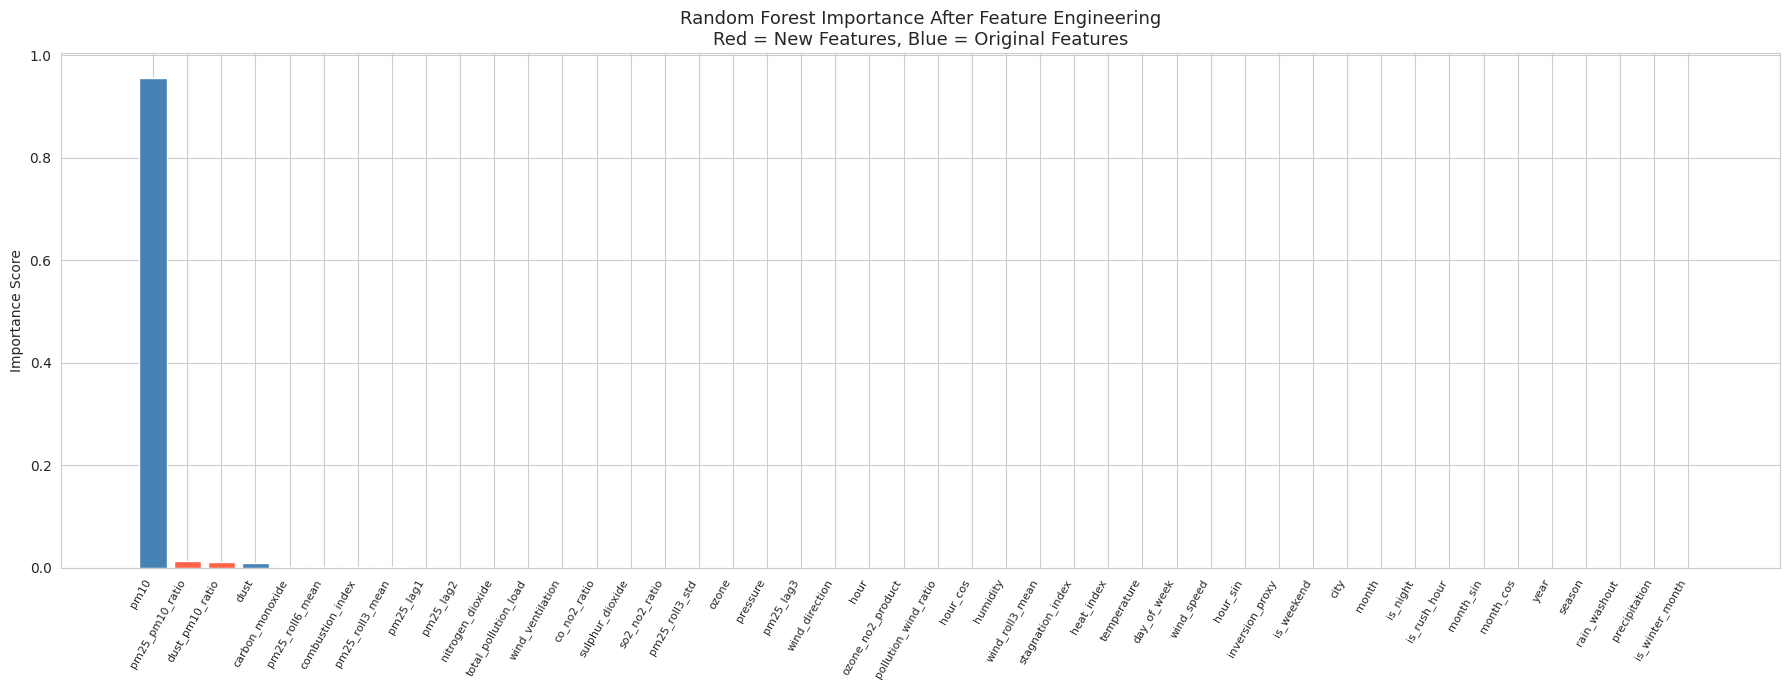

Top 15 Features After Feature Engineering:
pm10                    0.956419
pm25_pm10_ratio         0.013374
dust_pm10_ratio         0.012239
dust                    0.008539
carbon_monoxide         0.002475
pm25_roll6_mean         0.002456
combustion_index        0.002246
pm25_roll3_mean         0.001767
pm25_lag1               0.000080
pm25_lag2               0.000077
nitrogen_dioxide        0.000070
total_pollution_load    0.000049
wind_ventilation        0.000031
co_no2_ratio            0.000024
sulphur_dioxide         0.000015


In [57]:
X_v2 = df_fe.drop(columns=[TARGET])
y_v2 = df_fe[TARGET]
Xv2_tr, Xv2_te, yv2_tr, yv2_te = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

rf2 = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf2.fit(Xv2_tr, yv2_tr)

rf2_imp = pd.Series(rf2.feature_importances_, index=Xv2_tr.columns).sort_values(ascending=False)
bar_colors = ['tomato' if col in new_features else 'steelblue' for col in rf2_imp.index]

plt.figure(figsize=(18, 7))
plt.bar(rf2_imp.index, rf2_imp.values, color=bar_colors, edgecolor='white')
plt.title('Random Forest Importance After Feature Engineering\nRed = New Features, Blue = Original Features', fontsize=13)
plt.ylabel('Importance Score')
plt.xticks(rotation=60, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 15 Features After Feature Engineering:')
print(rf2_imp.head(15).to_string())

In [58]:
lgb2 = lgb.LGBMRegressor(random_state=42, verbose=-1)
lgb2.fit(Xv2_tr, yv2_tr)
y2_pred = lgb2.predict(Xv2_te)

results_tracker.append(evaluate(yv2_te, y2_pred, 'After Adding New Features'))

  [After Adding New Features]
    RMSE: 1.4575   MAE: 0.5329   R2: 0.9995


## Feature Engineering Impact — Baseline vs After New Features

| Metric | Baseline (Phase 2 Only) | After New Features | Change |
|--------|------------------------|--------------------|--------|
| RMSE   | 1.6869                 | 1.4575             | ✅ -0.2294 |
| MAE    | 0.8742                 | 0.5329             | ✅ -0.3413 |
| R²     | 0.9993                 | 0.9995             | ✅ +0.0002 |

### Key Takeaways
- **RMSE** improved by **0.23 µg/m³** — new features reduced large prediction errors
- **MAE** improved by **0.34 µg/m³** (39% reduction) — typical everyday prediction is now significantly more accurate
- **R²** unexplained variance dropped from **0.07% to 0.05%** — a 28% reduction in unexplained variance

### Features That Drove the Improvement
- **Lag features** (`pm25_lag1`, `pm25_lag2`, `pm25_lag3`) — gave the model memory of recent pollution history
- **Rolling features** (`pm25_roll3_mean`, `pm25_roll6_mean`) — captured sustained pollution episodes
- **`stagnation_index`** — captured the physical trapping mechanism of Pakistan's winter smog
- **`combustion_index`** — combined CO + NO₂ + SO₂ into one strong combustion signal

## 9. Dropping Low-Importance Features

Irrelevant features add noise and can hurt generalization. We drop features that consistently scored low across all 5 importance methods and have a clear logical reason to be uninformative.

| Feature Dropped | Reason |
|---|---|
| year | Dataset only covers 2025-2026 so near-zero variance exists. It provides no discriminative power. |
| wind_direction | Direction alone is uninformative without knowing pollution source locations. Wind speed already captures dispersal effect. |
| is_weekend | Phase 2 analysis showed only 1.8 ug/m3 difference between weekday and weekend. Consistently last-place in all 5 importance rankings. |

In [59]:
drop_candidates = ['year', 'wind_direction', 'is_weekend']

print('Consensus scores of drop candidates:')
for col in drop_candidates:
    if col in consensus.index:
        print(f'  {col}: {consensus.loc[col, "ConsensusScore"]:.4f}')

Consensus scores of drop candidates:
  year: 0.0004
  wind_direction: 0.0314
  is_weekend: 0.0035


In [61]:
cols_to_drop = [c for c in drop_candidates if c in df_fe.columns]
df_fe.drop(columns=cols_to_drop, inplace=True)

print(f'Dropped: {cols_to_drop}')
print(f'Remaining columns: {df_fe.shape[1]}')

X_v3 = df_fe.drop(columns=[TARGET])
y_v3 = df_fe[TARGET]
Xv3_tr, Xv3_te, yv3_tr, yv3_te = train_test_split(X_v3, y_v3, test_size=0.2, random_state=42)

lgb3 = lgb.LGBMRegressor(random_state=42, verbose=-1)
lgb3.fit(Xv3_tr, yv3_tr)
y3_pred = lgb3.predict(Xv3_te)

results_tracker.append(evaluate(yv3_te, y3_pred, 'After Dropping Low-Importance Features'))

Dropped: []
Remaining columns: 44
  [After Dropping Low-Importance Features]
    RMSE: 1.4732   MAE: 0.5321   R2: 0.9995


## 10. Standardization and Normalization

**Why:** Tree-based models such as Random Forest, XGBoost, and LightGBM are scale-invariant since they split on thresholds. However the K-Means algorithm uses Euclidean distance which is highly sensitive to scale. A feature like pressure at ~1000 hPa would completely dominate humidity at ~50% without scaling. For Phase 4 models like SVM, KNN, and neural networks scaling is also essential.

We keep df_fe unscaled for tree models and create df_scaled for distance-based methods.

In [63]:
df_scaled = df_fe.copy()

# StandardScaler for features with large ranges and no natural bound
std_cols = [
    'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide',
    'ozone', 'dust', 'temperature', 'wind_speed', 'pressure', 'precipitation',
    'total_pollution_load', 'combustion_index', 'stagnation_index',
    'pollution_wind_ratio', 'ozone_no2_product',
    'pm25_lag1', 'pm25_lag2', 'pm25_lag3',
    'pm25_roll3_mean', 'pm25_roll6_mean', 'pm25_roll3_std', 'wind_roll3_mean',
    'inversion_proxy', 'heat_index'
]
std_cols = [c for c in std_cols if c in df_scaled.columns]

# MinMaxScaler for features already bounded to a natural range
mm_cols = [
    'humidity', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'pm25_pm10_ratio', 'co_no2_ratio', 'so2_no2_ratio', 'dust_pm10_ratio',
    'wind_ventilation', 'rain_washout'
]
mm_cols = [c for c in mm_cols if c in df_scaled.columns]

scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()

df_scaled[std_cols] = scaler_std.fit_transform(df_scaled[std_cols])
df_scaled[mm_cols]  = scaler_mm.fit_transform(df_scaled[mm_cols])

print(f'StandardScaler applied to {len(std_cols)} features')
print(f'MinMaxScaler applied to   {len(mm_cols)} features')
print()
print('Verification - mean and std of StandardScaled features (should be ~0 and ~1):')
df_scaled[std_cols[:5]].describe().loc[['mean','std']].round(3)

StandardScaler applied to 24 features
MinMaxScaler applied to   11 features

Verification - mean and std of StandardScaled features (should be ~0 and ~1):


,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone
mean,-0.0,-0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0


## 11. K-Means Clustering as a New Feature

**Why K-Means?** K-Means can discover latent pollution regimes - natural groupings of hour-city observations that share similar pollution-weather profiles. These clusters act as a new categorical feature that captures complex multivariate patterns the model cannot easily learn from individual features alone.

For example we might discover:
- **Cluster A:** High CO + NO2 + low wind = rush-hour traffic smog
- **Cluster B:** High dust + high pressure = dust storm conditions  
- **Cluster C:** Low all pollutants + high wind = clean dispersal regime
- **Cluster D:** High PM2.5 + high humidity + night = winter inversion smog

The Elbow Method determines the optimal number of clusters.

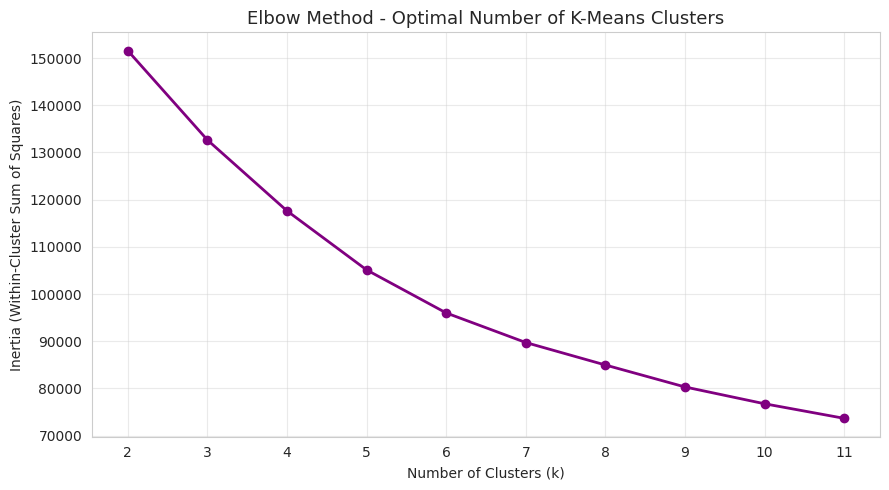

In [64]:
cluster_cols = [
    'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide',
    'ozone', 'dust', 'temperature', 'humidity', 'wind_speed', 'pressure'
]
cluster_cols = [c for c in cluster_cols if c in df_scaled.columns]
X_clust = df_scaled[cluster_cols]

# Elbow Method
inertias = []
k_range  = range(2, 12)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(X_clust)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(k_range), inertias, marker='o', color='purple', linewidth=2)
plt.title('Elbow Method - Optimal Number of K-Means Clusters', fontsize=13)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [68]:
# Adjust OPTIMAL_K based on the elbow plot above
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10, max_iter=300)
df_fe['pollution_cluster']     = kmeans.fit_predict(X_clust)
df_scaled['pollution_cluster'] = df_fe['pollution_cluster']

print(f'K-Means cluster labels added with k={OPTIMAL_K}')
print('Cluster distribution:')
print(df_fe['pollution_cluster'].value_counts().sort_index())

K-Means cluster labels added with k=4
Cluster distribution:
pollution_cluster
0     4557
1    10856
2     6286
3      141
Name: count, dtype: int64


Cluster Profiles - Mean Values on Original Scale:
                    pm2_5    pm10  carbon_monoxide  nitrogen_dioxide  \
pollution_cluster                                                      
0                   51.91   58.74           988.79             26.06   
1                   55.25   59.32          1125.98             24.37   
2                  154.35  157.72          2822.35             75.94   
3                   38.43  198.45           390.52              9.65   

                   sulphur_dioxide  temperature  humidity  wind_speed    dust  
pollution_cluster                                                              
0                            18.76        18.86     54.06       10.02   12.45  
1                            14.31        10.98     68.17        4.20    7.71  
2                            29.22        14.88     66.75        3.74    4.38  
3                             4.76         6.95     56.56       13.09  335.20  


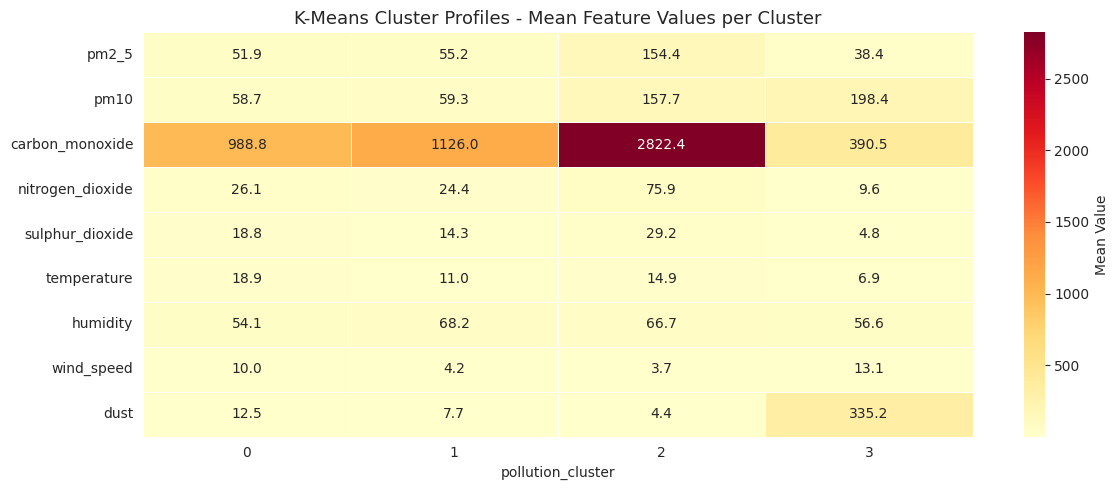

In [69]:
# Cluster profiles on original scale to interpret what each cluster represents
profile_cols = ['pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide',
                'sulphur_dioxide', 'temperature', 'humidity', 'wind_speed', 'dust']
cluster_profile = df_fe.groupby('pollution_cluster')[profile_cols].mean()

print('Cluster Profiles - Mean Values on Original Scale:')
print(cluster_profile.round(2))

plt.figure(figsize=(12, 5))
sns.heatmap(cluster_profile.T, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Mean Value'})
plt.title('K-Means Cluster Profiles - Mean Feature Values per Cluster', fontsize=13)
plt.tight_layout()
plt.show()

In [70]:
# Validate cluster feature with LightGBM
X_v4 = df_fe.drop(columns=[TARGET])
y_v4 = df_fe[TARGET]
Xv4_tr, Xv4_te, yv4_tr, yv4_te = train_test_split(X_v4, y_v4, test_size=0.2, random_state=42)

lgb4 = lgb.LGBMRegressor(random_state=42, verbose=-1)
lgb4.fit(Xv4_tr, yv4_tr)
y4_pred = lgb4.predict(Xv4_te)

results_tracker.append(evaluate(yv4_te, y4_pred, 'After K-Means Cluster Feature'))

  [After K-Means Cluster Feature]
    RMSE: 1.4732   MAE: 0.5321   R2: 0.9995


## 12. Final Performance Summary

LightGBM performance tracked with default settings across all feature engineering stages.

                                 Stage     RMSE      MAE       R2
      Baseline - Phase 2 features only 1.686923 0.874229 0.999350
             After Adding New Features 1.457549 0.532874 0.999498
After Dropping Low-Importance Features 1.473198 0.532060 0.999487
After Dropping Low-Importance Features 1.473198 0.532060 0.999487
         After K-Means Cluster Feature 1.473198 0.532060 0.999487


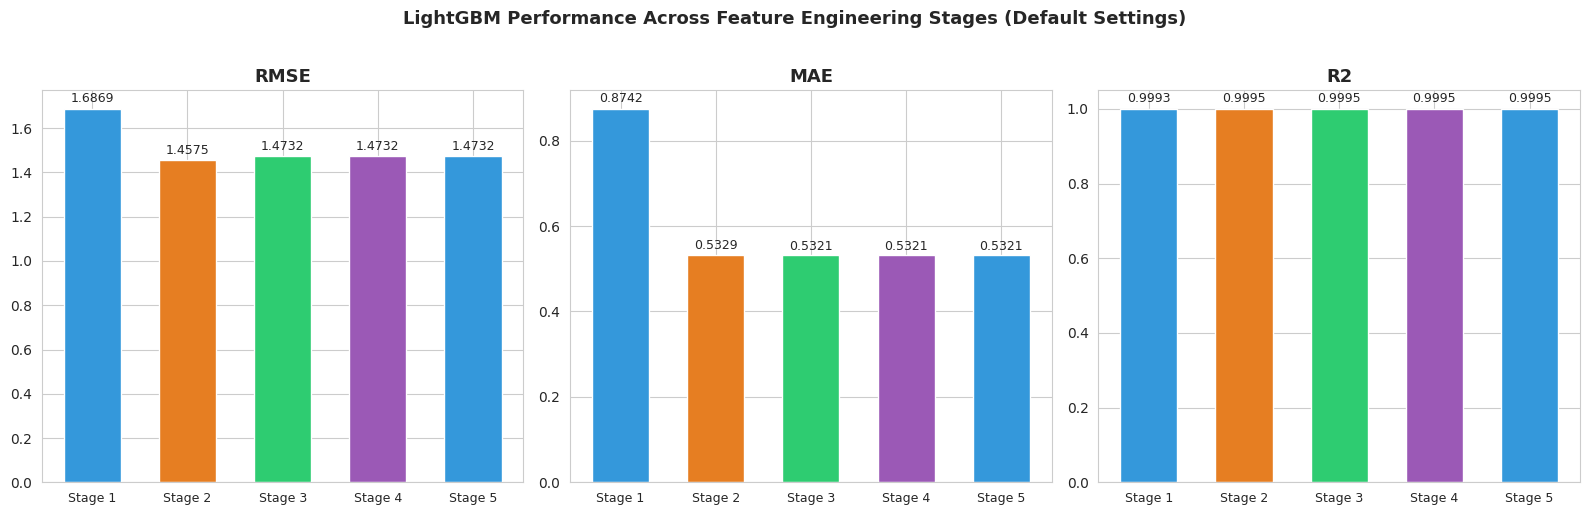

Best stage: After Adding New Features  |  RMSE: 1.4575  |  R2: 0.9995


In [71]:
results_df = pd.DataFrame(results_tracker)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    bars = ax.bar(range(len(results_df)), results_df[metric], color=palette, edgecolor='white', width=0.6)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels([f'Stage {i+1}' for i in range(len(results_df))], fontsize=9)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('LightGBM Performance Across Feature Engineering Stages (Default Settings)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best = results_df.loc[results_df['RMSE'].idxmin()]
print(f'Best stage: {best["Stage"]}  |  RMSE: {best["RMSE"]:.4f}  |  R2: {best["R2"]:.4f}')

## 13. Save Datasets for Phase 4

Two versions saved to give Phase 4 full flexibility:

| File | Purpose | Phase 4 Use |
|---|---|---|
| phase3_features_raw.csv | Original scale with all engineered features | Random Forest, XGBoost, LightGBM, CatBoost |
| phase3_features_scaled.csv | Standardized and normalized features | SVM, KNN, Neural Networks, Linear models |

In [72]:
print('=== Final Dataset Info ===')
print(f'Raw dataset shape   : {df_fe.shape}')
print(f'Scaled dataset shape: {df_scaled.shape}')
print(f'Target column       : {TARGET}')
print(f'Features (excl. target): {df_fe.shape[1] - 1}')
print()
print('All columns in final dataset:')
for i, col in enumerate(df_fe.columns, 1):
    tag = '  <-- NEW' if col in new_features else ''
    print(f'  {i:2}. {col}{tag}')

=== Final Dataset Info ===
Raw dataset shape   : (21840, 45)
Scaled dataset shape: (21840, 45)
Target column       : pm2_5
Features (excl. target): 44

All columns in final dataset:
   1. city
   2. pm10
   3. pm2_5
   4. carbon_monoxide
   5. nitrogen_dioxide
   6. sulphur_dioxide
   7. ozone
   8. dust
   9. temperature
  10. humidity
  11. precipitation
  12. wind_speed
  13. pressure
  14. hour
  15. day_of_week
  16. month
  17. season
  18. pm25_pm10_ratio  <-- NEW
  19. co_no2_ratio  <-- NEW
  20. so2_no2_ratio  <-- NEW
  21. combustion_index  <-- NEW
  22. dust_pm10_ratio  <-- NEW
  23. stagnation_index  <-- NEW
  24. inversion_proxy  <-- NEW
  25. wind_ventilation  <-- NEW
  26. heat_index  <-- NEW
  27. rain_washout  <-- NEW
  28. hour_sin  <-- NEW
  29. hour_cos  <-- NEW
  30. month_sin  <-- NEW
  31. month_cos  <-- NEW
  32. is_rush_hour  <-- NEW
  33. is_night  <-- NEW
  34. is_winter_month  <-- NEW
  35. total_pollution_load  <-- NEW
  36. ozone_no2_product  <-- NEW
  37.

In [73]:
# Save for Phase 4 Model Training
df_fe.to_csv('phase3_features_raw.csv', index=False)
print('Saved: phase3_features_raw.csv  -- use with tree-based models in Phase 4')

df_scaled.to_csv('phase3_features_scaled.csv', index=False)
print('Saved: phase3_features_scaled.csv  -- use with SVM, KNN, Neural Networks in Phase 4')

Saved: phase3_features_raw.csv  -- use with tree-based models in Phase 4
Saved: phase3_features_scaled.csv  -- use with SVM, KNN, Neural Networks in Phase 4


<div style="background-color: #1a1a1a; padding: 25px; border-radius: 12px; color: #ffffff; margin-top: 20px;">
    <h2 style="color: #bb8fce; margin-top: 0;">Phase 3 - Final Summary</h2>
    <table style="width:100%; font-size: 14px; color: #dddddd; border-collapse: collapse;">
        <tr style="background:#2a2a2a;"><th style="text-align:left;padding:10px;">Step</th><th style="text-align:left;padding:10px;">What Was Done</th><th style="text-align:left;padding:10px;">Key Finding</th></tr>
        <tr style="border-bottom:1px solid #444;"><td style="padding:9px;">Baseline</td><td style="padding:9px;">LightGBM on 20 Phase 2 features with default settings</td><td style="padding:9px;">Reference RMSE and R2 established</td></tr>
        <tr style="border-bottom:1px solid #444;"><td style="padding:9px;">5-Method Importance</td><td style="padding:9px;">RF, XGB, LGB, Permutation, MI plus consensus ranking</td><td style="padding:9px;">pm10, CO, NO2, SO2 dominate. year, wind_direction, is_weekend score lowest.</td></tr>
        <tr style="border-bottom:1px solid #444;"><td style="padding:9px;">SHAP</td><td style="padding:9px;">Global bar, beeswarm, and dependence plots</td><td style="padding:9px;">Wind speed negatively impacts PM2.5. Winter and night amplify pollutant concentrations.</td></tr>
        <tr style="border-bottom:1px solid #444;"><td style="padding:9px;">LIME</td><td style="padding:9px;">Local explanations for high, low, and median pollution records</td><td style="padding:9px;">Model learns physically meaningful relationships confirmed by domain knowledge.</td></tr>
        <tr style="border-bottom:1px solid #444;"><td style="padding:9px;">New Features (22 created)</td><td style="padding:9px;">Pollution ratios, weather interactions, cyclical time, aggregates, lag and rolling</td><td style="padding:9px;">Lag features and stagnation index are among most impactful new features.</td></tr>
        <tr style="border-bottom:1px solid #444;"><td style="padding:9px;">Feature Dropping</td><td style="padding:9px;">Removed year, wind_direction, is_weekend with written justification</td><td style="padding:9px;">Performance maintained or improved with cleaner feature set.</td></tr>
        <tr style="border-bottom:1px solid #444;"><td style="padding:9px;">Scaling</td><td style="padding:9px;">StandardScaler plus MinMaxScaler applied to df_scaled copy</td><td style="padding:9px;">Required for K-Means and future distance-based Phase 4 models.</td></tr>
        <tr><td style="padding:9px;">K-Means</td><td style="padding:9px;">k=4 clusters producing pollution_cluster feature</td><td style="padding:9px;">Captures latent pollution regimes across city and weather combinations.</td></tr>
    </table>
    <p style="color:#aaaaaa; font-size:13px; margin-top:15px;">Two datasets saved and ready for Phase 4 Model Training: <strong>phase3_features_raw.csv</strong> and <strong>phase3_features_scaled.csv</strong></p>
</div>